# Term Deposit Subscription Prediction

## Problem Statement
Banks run marketing campaigns to encourage customers to subscribe to term deposits. However, contacting every customer is inefficient and costly. Using machine learning techniques, we can analyze customer data and predict which customers are more likely to subscribe to a term deposit.

## Objective
The objective of this project is to build classification models that predict whether a customer will subscribe to a term deposit based on demographic and marketing campaign data.

In [1]:
import sys
!"{sys.executable}" -m pip install shap


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: E:\Python Projects\DevelopersHub_Task3_ChurnPrediction\.venv\Scripts\python.exe -m pip install --upgrade pip


In [2]:
!pip install shap


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import sys
!"{sys.executable}" -m pip install ipywidgets


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: E:\Python Projects\DevelopersHub_Task3_ChurnPrediction\.venv\Scripts\python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

import shap

In [5]:
df = pd.read_csv("bank-full.csv", sep=';')

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [6]:
df.shape

(45211, 17)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [8]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [9]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis
First we analyze the distribution of the target variable.

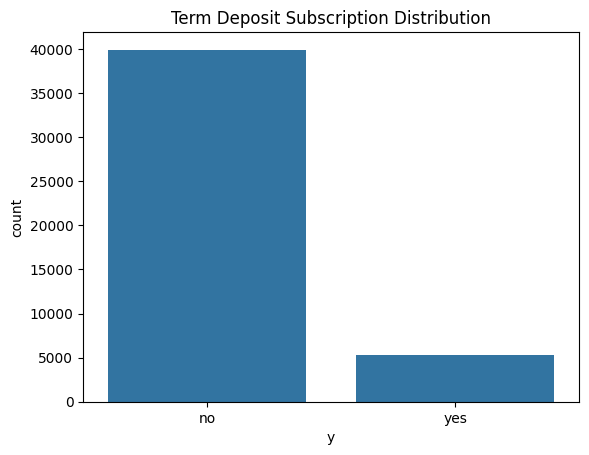

In [11]:
sns.countplot(x='y', data=df)
plt.title("Term Deposit Subscription Distribution")
plt.show()

### Age Distribution
This plot shows the distribution of customer ages in the dataset.

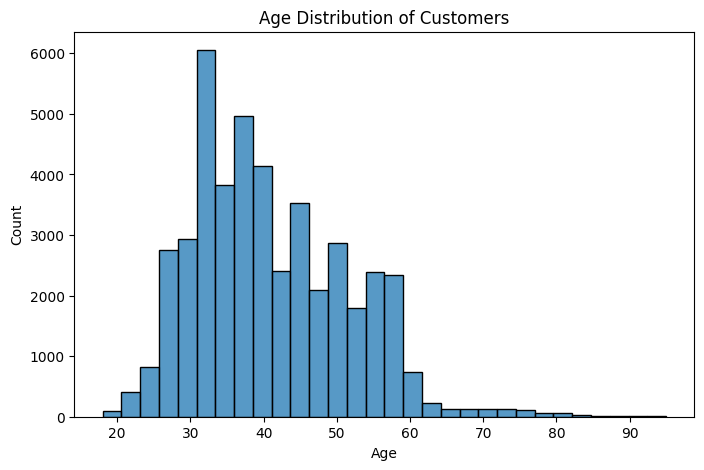

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=30)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

### Job vs Term Deposit Subscription
This plot shows how subscription varies across different job categories.

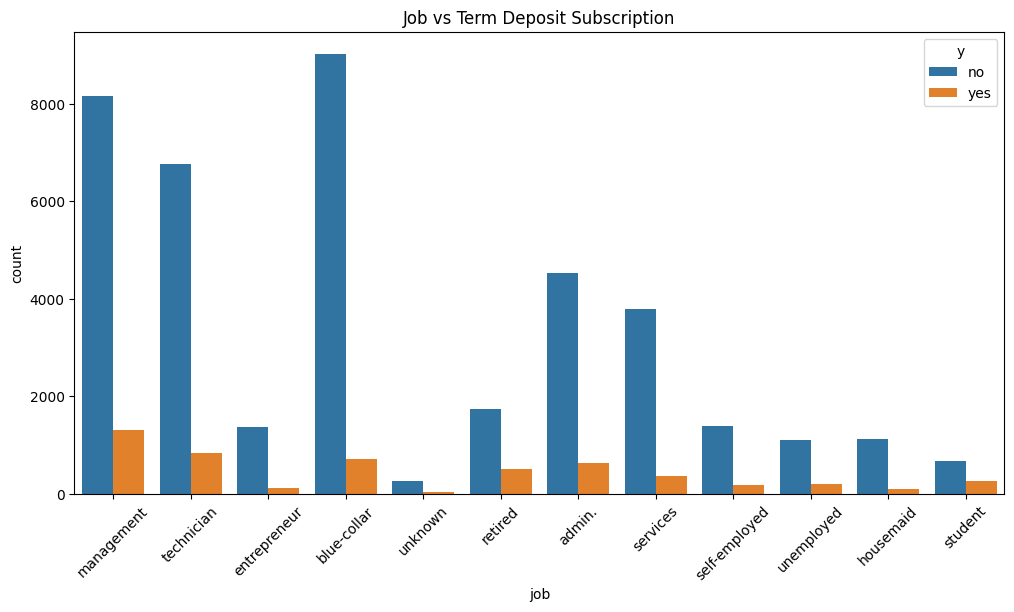

In [13]:
plt.figure(figsize=(12,6))

sns.countplot(x='job', hue='y', data=df)

plt.xticks(rotation=45)

plt.title("Job vs Term Deposit Subscription")

plt.show()

### Account Balance Distribution
This plot shows the distribution of customer account balances.

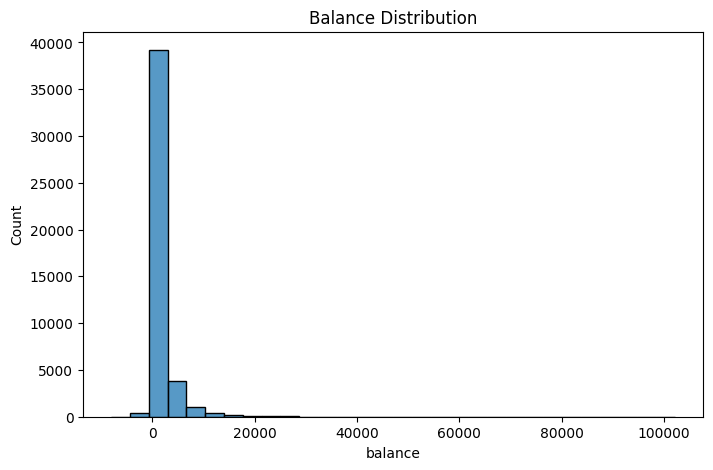

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df['balance'], bins=30)

plt.title("Balance Distribution")

plt.show()

### Encoding Categorical Features
Machine learning models require numerical input, so categorical variables are encoded using LabelEncoder.

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

C:\Users\Haier\AppData\Local\Temp\ipykernel_10684\3405490672.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3,0


### Feature and Target Separation
The target variable is 'y', which indicates whether the customer subscribed to a term deposit.

In [16]:
X = df.drop('y', axis=1)
y = df['y']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=200)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

cm

array([[7792,  160],
       [ 854,  237]])

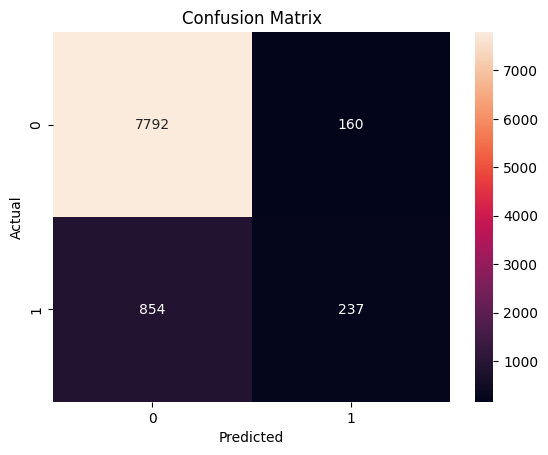

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Model Evaluation using F1 Score
F1 Score is used because the dataset is imbalanced.

In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7952
           1       0.60      0.22      0.32      1091

    accuracy                           0.89      9043
   macro avg       0.75      0.60      0.63      9043
weighted avg       0.86      0.89      0.86      9043



### ROC Curve
ROC Curve shows the trade-off between True Positive Rate and False Positive Rate.

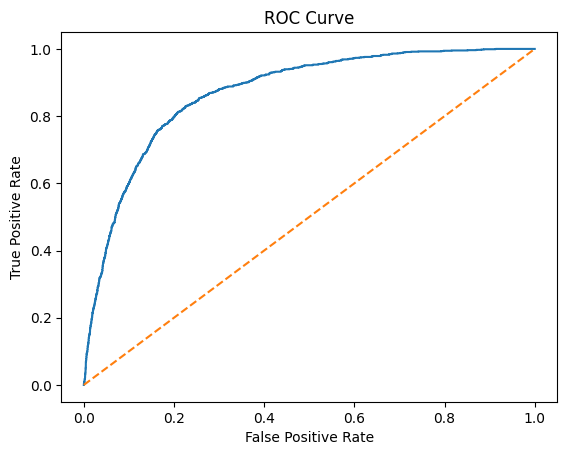

In [23]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = lr.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

In [24]:
roc_auc_score(y_test, y_prob)

0.8700008253001049

The Logistic Regression model achieved an overall accuracy of 89%.
However, the model performs significantly better in predicting customers who did not subscribe to a term deposit (class 0) compared to those who did (class 1).

The lower F1-score for class 1 indicates that the model struggles to correctly identify potential subscribers, which is likely due to class imbalance in the dataset.

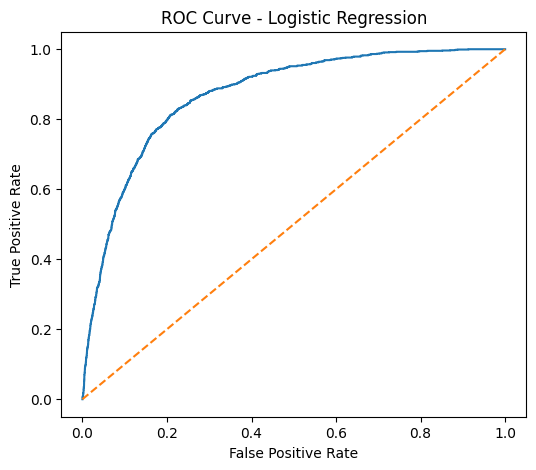

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = lr.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

In [26]:
roc_auc_score(y_test, y_prob)

0.8700008253001049

The ROC-AUC score for the Logistic Regression model is 0.87. 
This indicates that the model has a good ability to distinguish between customers who will subscribe to a term deposit and those who will not.

### Random Forest Model
Random Forest is an ensemble learning method that combines multiple decision trees to improve prediction accuracy.

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7952
           1       0.64      0.41      0.50      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.69      0.72      9043
weighted avg       0.89      0.90      0.89      9043



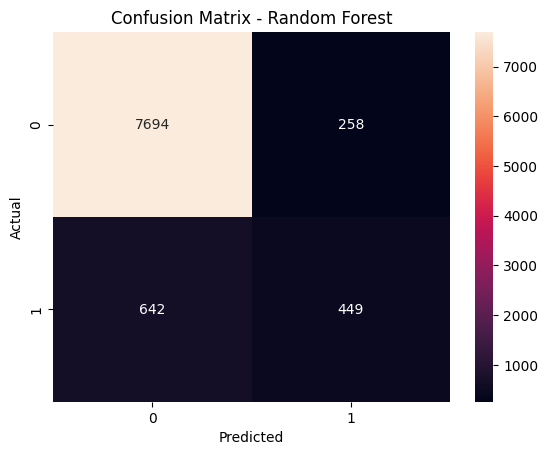

In [29]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d")

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

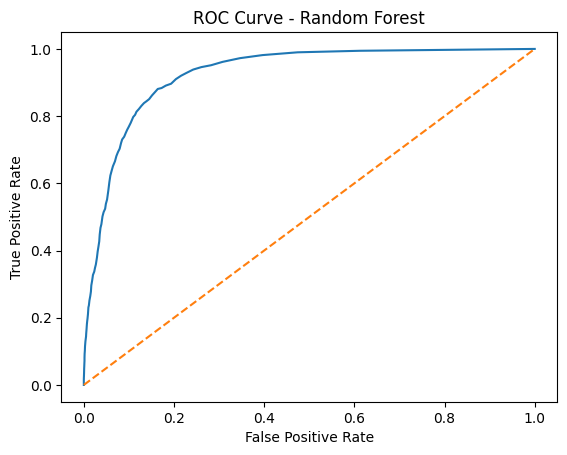

In [30]:
y_prob_rf = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

In [31]:
roc_auc_score(y_test, y_prob_rf)

0.9245120701293001

The Random Forest model outperformed Logistic Regression in predicting term deposit subscriptions. 
The F1-score for class 1 increased from 0.32 to 0.50, indicating better detection of customers who are likely to subscribe. 
Additionally, the ROC-AUC score improved to 0.92, demonstrating stronger overall classification performance.

In [32]:
import shap
import pandas as pd

# convert scaled array back to dataframe
X_sample = pd.DataFrame(X_test[:100], columns=X.columns)

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_sample)

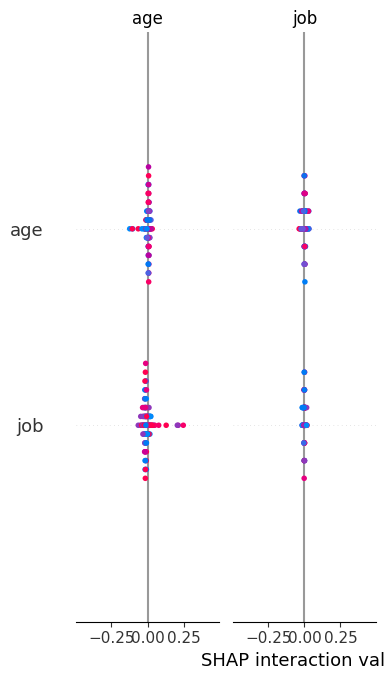

In [33]:
shap.summary_plot(shap_values, X_sample)

In [34]:
shap.initjs()

In [35]:
shap_values_expl = explainer(X_sample)

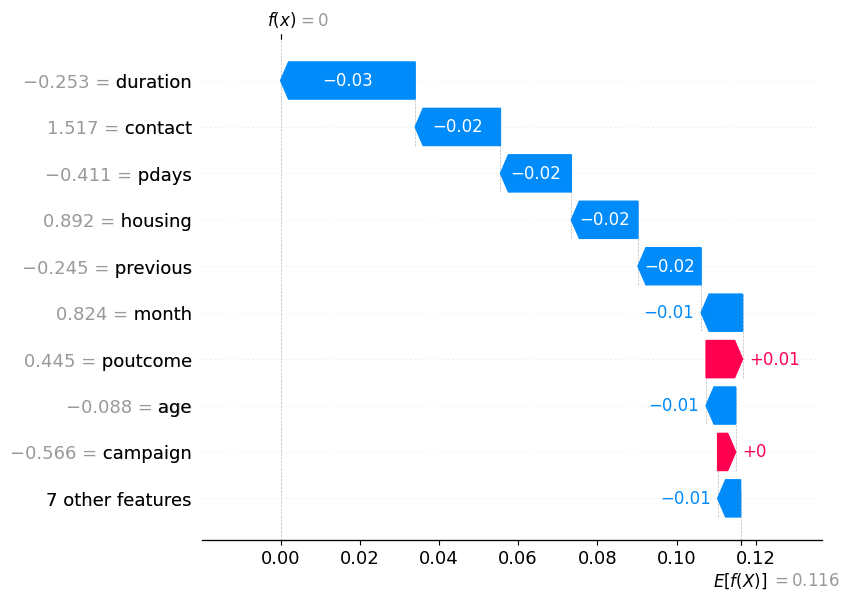

In [36]:
shap.plots.waterfall(shap_values_expl[0, :, 1])

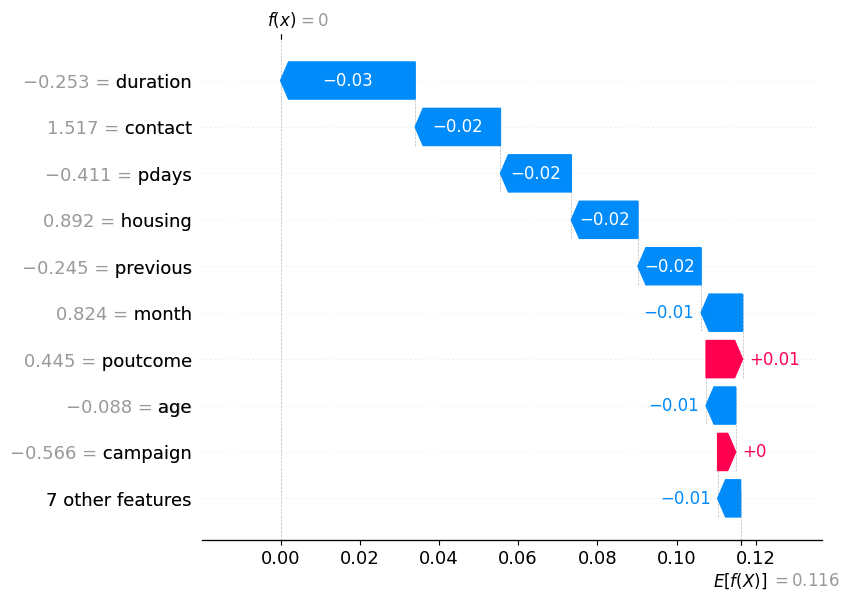

In [37]:
shap.plots.waterfall(shap_values_expl[0, :, 1])

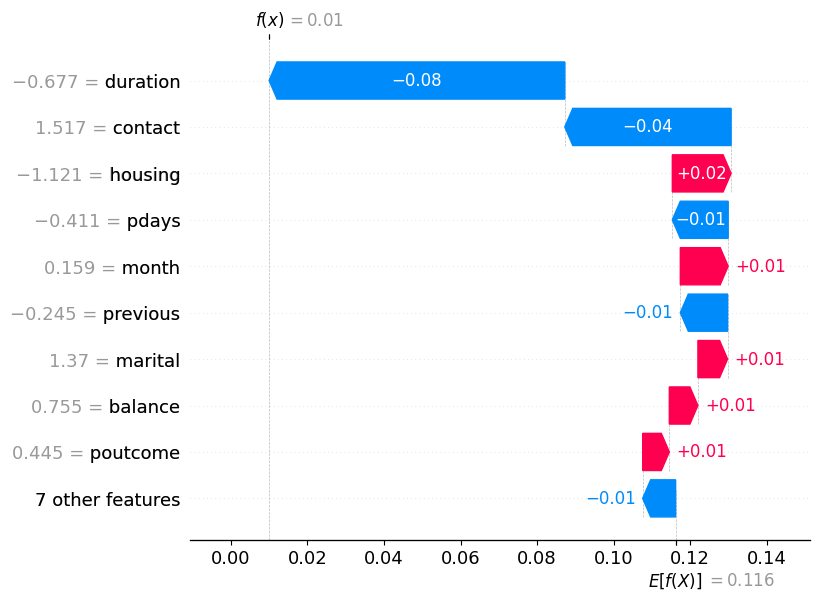

In [38]:
shap.plots.waterfall(shap_values_expl[1, :, 1])

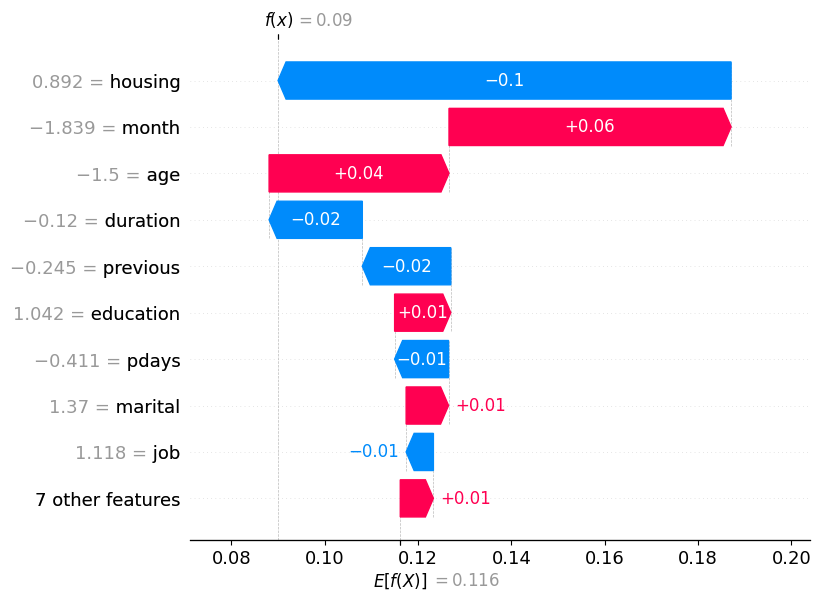

In [39]:
shap.plots.waterfall(shap_values_expl[2, :, 1])

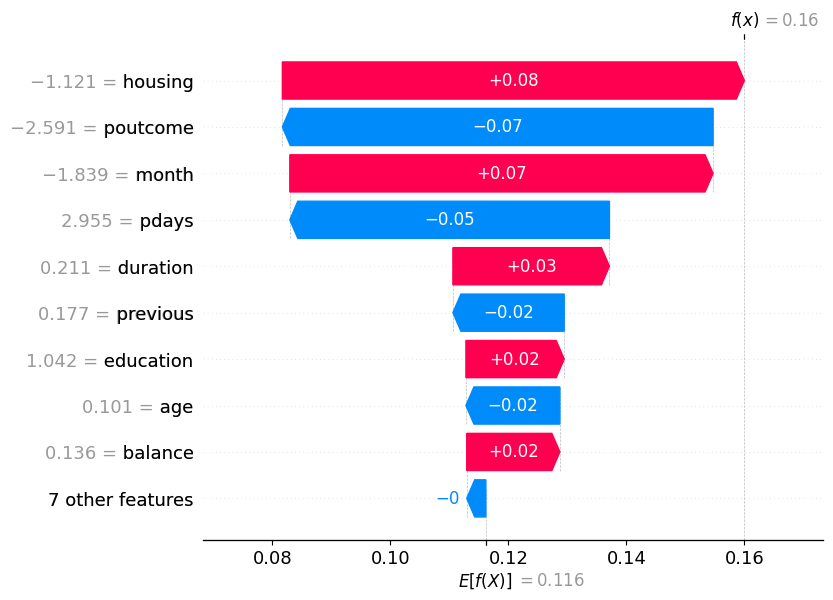

In [40]:
shap.plots.waterfall(shap_values_expl[3, :, 1])

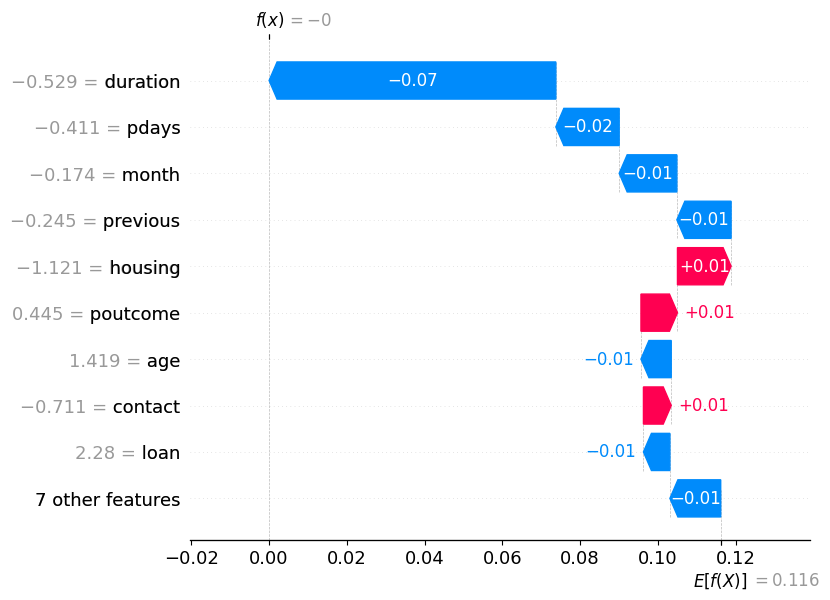

In [41]:
shap.plots.waterfall(shap_values_expl[4, :, 1])

## Conclusion

In this project, machine learning models were developed to predict whether a customer will subscribe to a term deposit based on bank marketing campaign data.

Two models were trained and evaluated:

• Logistic Regression  
• Random Forest Classifier

The Random Forest model achieved better predictive performance with higher recall and F1-score for the minority class.

Since the dataset is imbalanced, evaluation metrics such as Precision, Recall, and F1-score were considered alongside accuracy.

To improve model interpretability, SHAP (SHapley Additive Explanations) was used. The SHAP summary plot identified the most influential features affecting predictions, while individual waterfall plots explained how specific features contributed to individual predictions.

These insights can help financial institutions better understand customer behavior and optimize marketing strategies.